# Diabetes readmission ranking

This report uses the production loader and patient split. Exploration is limited to the training partition; final-test results are loaded from the completed verification report.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from diabetes_readmission_ranking.config import PROJECT_ROOT
from diabetes_readmission_ranking.data import eligible_encounters, load_encounters, split_by_patient

sns.set_theme(style="whitegrid")
partitions = split_by_patient(eligible_encounters(load_encounters()))
train = partitions.train
report = json.loads((PROJECT_ROOT / "verification.json").read_text(encoding="utf-8"))
print("Data source: data/diabetic_data.csv")
print(f"Training encounters: {len(train):,}; training patients: {train.patient_nbr.nunique():,}")
print(f"30-day readmission rate: {train.target.mean():.1%}")
print(f"Patient overlap: {sum(report['dataset']['patient_overlap'].values())}")

Data source: data/diabetic_data.csv
Training encounters: 69,678; training patients: 48,992
30-day readmission rate: 11.3%
Patient overlap: 0


The training partition contains 69,678 encounters from 48,992 patients. The positive class is uncommon at 11.3%, so PR-AUC and capacity-based recall are more useful than accuracy.

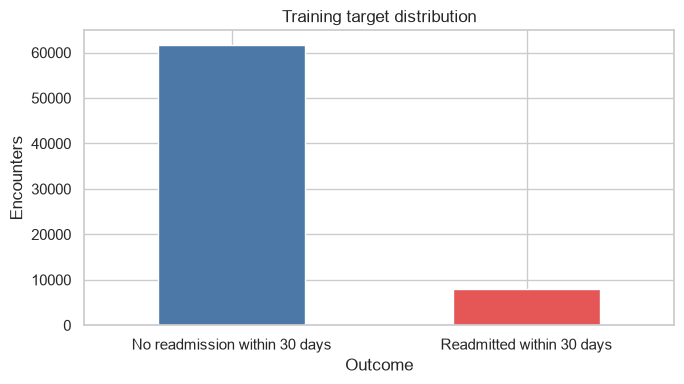

In [2]:
counts = train.target.value_counts().sort_index()
ax = counts.rename({0: "No readmission within 30 days", 1: "Readmitted within 30 days"}).plot.bar(color=["#4C78A8", "#E45756"], figsize=(7, 4))
ax.set(title="Training target distribution", xlabel="Outcome", ylabel="Encounters")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Missingness is concentrated: weight, glucose testing, A1C results, specialty, and payer code are incomplete. Missing categories are retained explicitly rather than filled from later records.

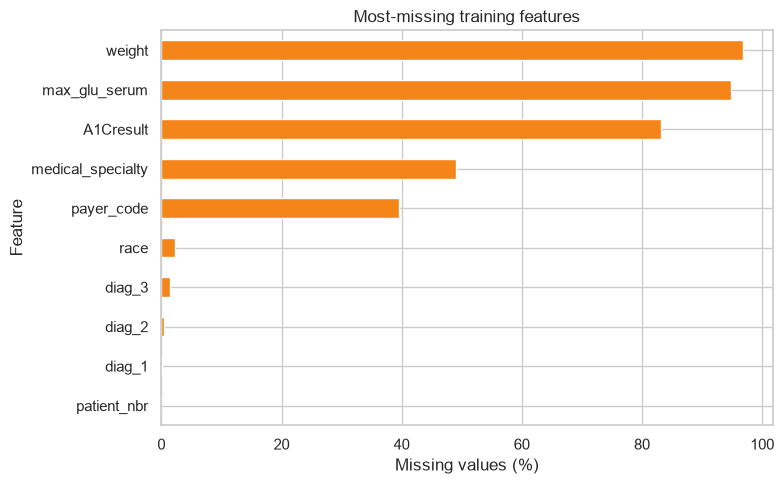

In [3]:
missing = train.isna().mean().sort_values(ascending=False).head(10).mul(100)
ax = missing.sort_values().plot.barh(color="#F58518", figsize=(8, 5))
ax.set(title="Most-missing training features", xlabel="Missing values (%)", ylabel="Feature")
plt.tight_layout()
plt.show()

Training readmission rates generally rise through older age bands, reaching 12.8% for ages 80–90. The smallest and youngest bands have limited samples and should not drive conclusions.

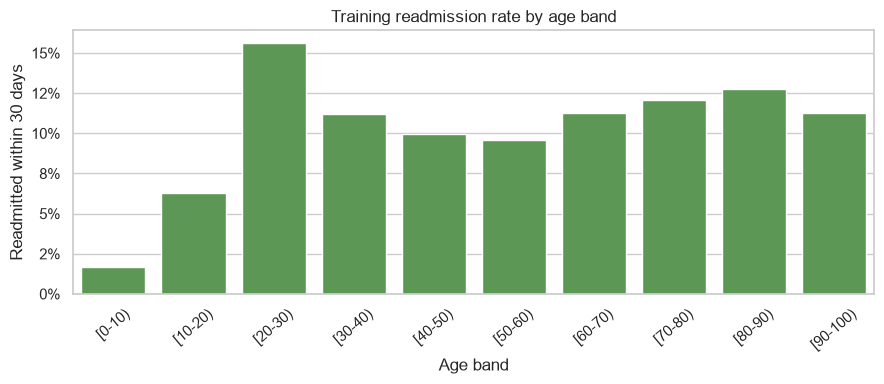

In [4]:
age_summary = train.groupby("age", observed=True).target.agg(["size", "mean"]).reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=age_summary, x="age", y="mean", color="#54A24B", ax=ax)
ax.set(title="Training readmission rate by age band", xlabel="Age band", ylabel="Readmitted within 30 days")
ax.tick_params(axis="x", rotation=40)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

CatBoost had the strongest training-only validation PR-AUC. On the untouched test partition, it also captured 55 more readmissions than logistic regression at the same capacity.

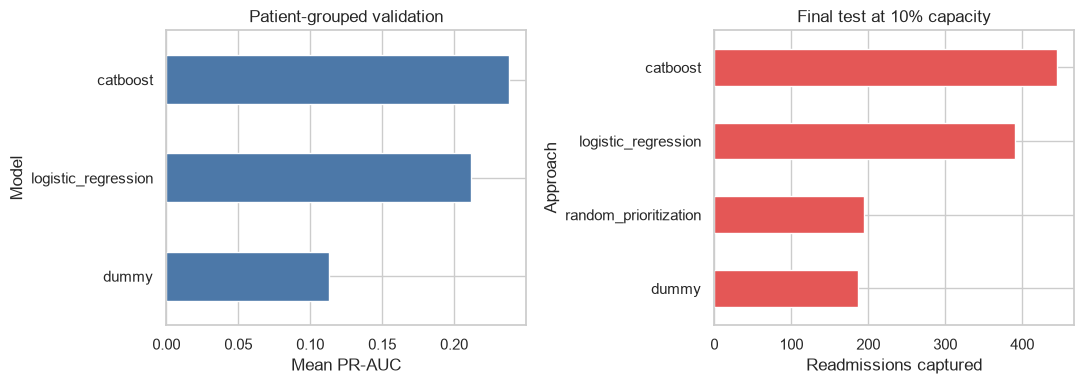

In [5]:
comparison = pd.DataFrame(report["selection"]["comparison"]).T
test = pd.DataFrame(report["test"]).T
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comparison.validation_pr_auc.sort_values().plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set(title="Patient-grouped validation", xlabel="Mean PR-AUC", ylabel="Model")
test.readmissions_captured.dropna().sort_values().plot.barh(ax=axes[1], color="#E45756")
axes[1].set(title="Final test at 10% capacity", xlabel="Readmissions captured", ylabel="Approach")
plt.tight_layout()
plt.show()

Isotonic calibration reduced test Brier score from 0.09666 to 0.09657. This is a small improvement, but it meets the requirement without using test data to choose the method.

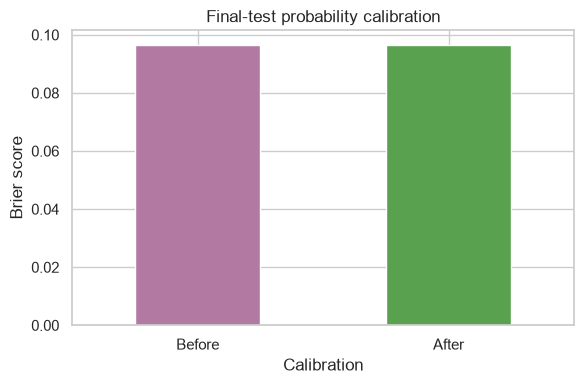

In [6]:
calibration = report["calibration"]
values = pd.Series({"Before": calibration["test_brier_before"], "After": calibration["test_brier_after"]})
ax = values.plot.bar(color=["#B279A2", "#59A14F"], figsize=(6, 4))
ax.set(title="Final-test probability calibration", xlabel="Calibration", ylabel="Brier score")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Subgroup recall varies, but several groups contain few positive cases. These descriptive results are a warning for further review—not evidence that the model is fair or suitable for clinical use.

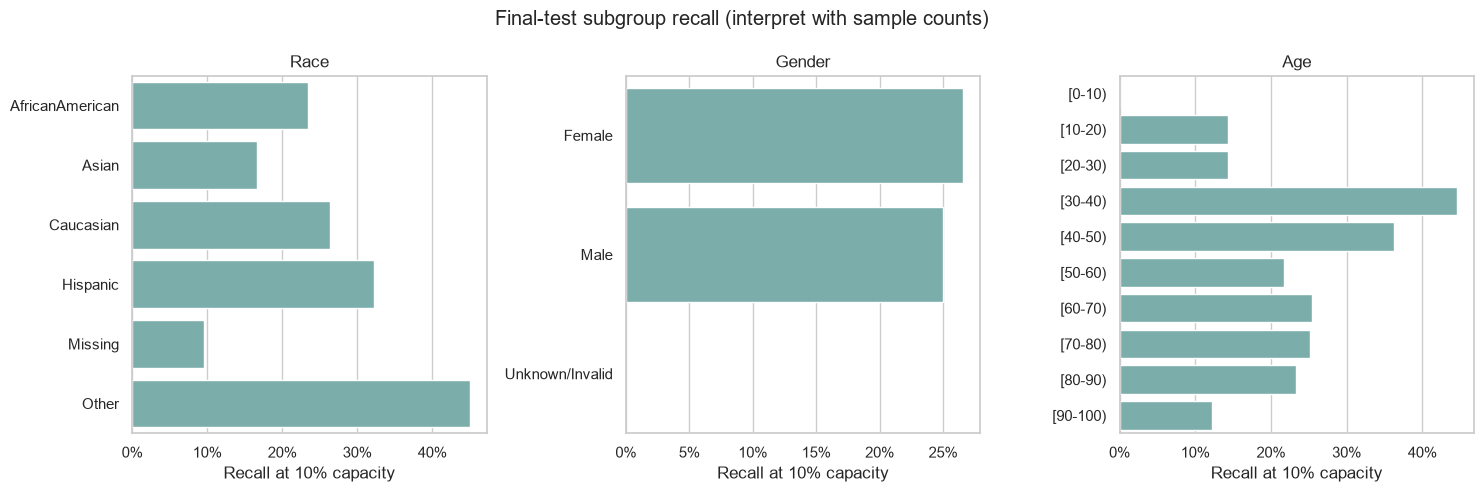

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, attribute in zip(axes, ("race", "gender", "age")):
    groups = pd.DataFrame(report["subgroups"][attribute])
    sns.barplot(data=groups, x="recall", y="group", color="#72B7B2", ax=ax)
    ax.set(title=attribute.title(), xlabel="Recall at 10% capacity", ylabel="")
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
fig.suptitle("Final-test subgroup recall (interpret with sample counts)")
plt.tight_layout()
plt.show()

## Key findings and implications

- CatBoost improves prioritization over logistic and random baselines, but still misses about 74% of readmissions at 10% capacity.
- Calibration improves slightly; current-data validation would still be required before probabilities informed decisions.
- High missingness and small subgroup samples need explicit monitoring and governance.
- The historical observational data cannot show that outreach changes outcomes. The result is an engineering exercise, not a clinically deployable system.